In [ ]:
# --- PART 1: SETUP AND DATA LOADING ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Load Data
BASE_PATH = '/content/drive/MyDrive/Capstone Test Data sets/'
trans_df = pd.read_csv(BASE_PATH + 'transactions.csv')
cust_df = pd.read_csv(BASE_PATH + 'customers.csv')
prod_df = pd.read_csv(BASE_PATH + 'products.csv')
items_df = pd.read_csv(BASE_PATH + 'order_items.csv')

print("✅ Part 1 Complete: All files loaded successfully.")

Mounted at /content/drive
✅ Part 1 Complete: All files loaded successfully.


In [ ]:
# --- PART 2: DATA CLEANING & FEATURE ENGINEERING ---

# CLEANING: Lowercase all columns to prevent capitalization errors
for temp_df in [trans_df, cust_df, prod_df, items_df]:
    temp_df.columns = temp_df.columns.str.strip().str.lower()

# Normalize price column name
if 'unit_price' in prod_df.columns: prod_df.rename(columns={'unit_price': 'price'}, inplace=True)
if 'unit_price' in items_df.columns: items_df.rename(columns={'unit_price': 'price'}, inplace=True)

# MERGE DATA
df = trans_df.merge(cust_df, on='customer_id')
df = df.merge(items_df, on='order_id')
df = df.merge(prod_df, on='product_id')

print(f"Data merged successfully! Total rows: {len(df)}")

# FEATURE ENGINEERING
df['order_date'] = pd.to_datetime(df['order_date'])

# Handle duplicate column names dynamically
price_col = 'price_y' if 'price_y' in df.columns else ('price_x' if 'price_x' in df.columns else 'price')
df['total_spent'] = df['quantity'] * df[price_col]

snapshot_date = df['order_date'].max() + timedelta(days=1)

# RFM Metrics Calculation
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_spent': 'sum'
}).rename(columns={'order_date': 'recency', 'order_id': 'frequency', 'total_spent': 'monetary'})

# Customer Segmentation
rfm['segment'] = pd.qcut(rfm['monetary'].rank(method='first'), q=3, labels=['Bronze', 'Silver', 'Gold'])

print("✅ Part 2 Complete: Feature engineering and RFM segmentation done.")

Data merged successfully! Total rows: 9036
✅ Part 2 Complete: Feature engineering and RFM segmentation done.


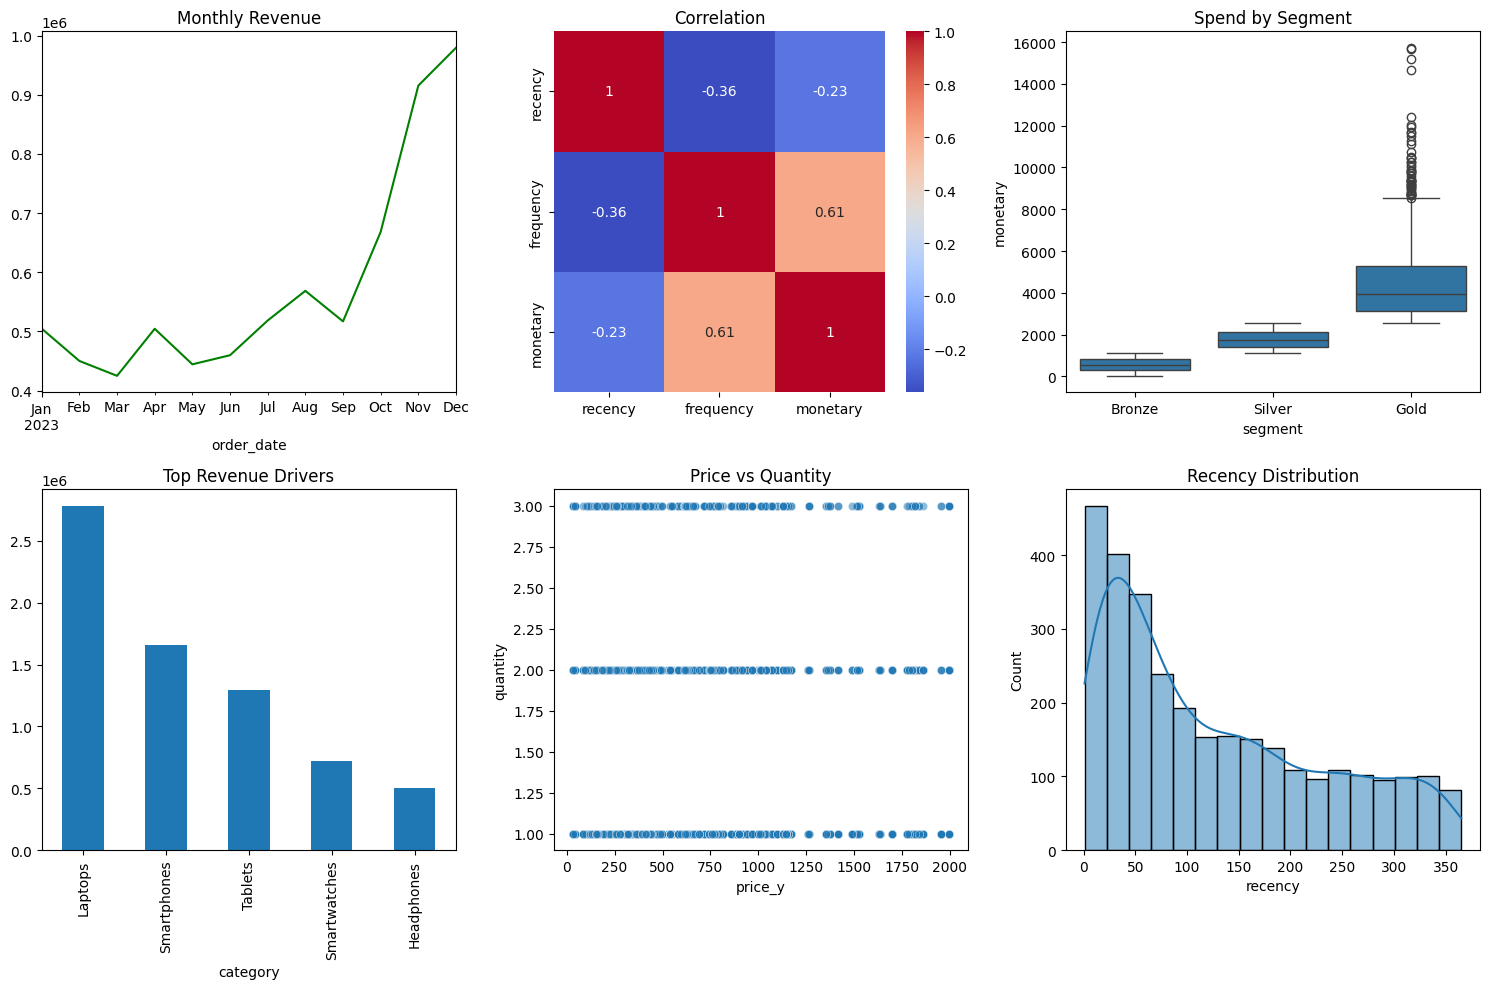

✅ Part 3 Complete: Visualizations generated.


In [ ]:
# --- PART 3: VISUALIZATIONS ---
plt.figure(figsize=(15, 10))

# 1. Revenue Trend
plt.subplot(2, 3, 1)
df.set_index('order_date')['total_spent'].resample('ME').sum().plot(title='Monthly Revenue', color='green')

# 2. Correlation Heatmap
plt.subplot(2, 3, 2)
sns.heatmap(rfm[['recency', 'frequency', 'monetary']].corr(), annot=True, cmap='coolwarm').set_title('Correlation')

# 3. Spend by Segment Boxplot
plt.subplot(2, 3, 3)
sns.boxplot(x='segment', y='monetary', data=rfm).set_title('Spend by Segment')

# 4. Category Performance
plt.subplot(2, 3, 4)
cat_col = 'category' if 'category' in df.columns else 'name'
df.groupby(cat_col)['total_spent'].sum().nlargest(10).plot(kind='bar', title='Top Revenue Drivers')

# 5. Price vs Sales Scatter
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x=price_col, y='quantity', alpha=0.5).set_title('Price vs Quantity')

# 6. Recency Distribution (Proxy for Cohort)
plt.subplot(2, 3, 6)
sns.histplot(rfm['recency'], kde=True).set_title('Recency Distribution')

plt.tight_layout()
plt.show()
print("✅ Part 3 Complete: Visualizations generated.")

In [ ]:
# --- PART 4: EXPLORATORY DATA ANALYSIS (EDA) ---
print("--- EXPLORATORY DATA ANALYSIS ---\n")

# FIX: Robustly find the product name column.
# It checks a list of common names, and falls back to 'product_id' if none exist.
possible_name_cols = ['product_name', 'name_y', 'name_x', 'name', 'title', 'item_name']
prod_name_col = 'product_id' # Foolproof fallback

for col in possible_name_cols:
    if col in df.columns:
        prod_name_col = col
        break

# 1. Top and Bottom 10 Products
product_sales = df.groupby(prod_name_col)['quantity'].sum().sort_values(ascending=False)
print(f"🔥 TOP 10 Products by Quantity Sold:")
print(product_sales.head(10))
print(f"\n🧊 BOTTOM 10 Products by Quantity Sold:")
print(product_sales.tail(10))

# 2. Peak Purchase Hours
df['hour'] = df['order_date'].dt.hour
peak_hour = df['hour'].value_counts().idxmax()
print(f"\n⏰ Peak Shopping Hour: {peak_hour}:00")

# 3. Simple Outlier Detection
q3 = df['quantity'].quantile(0.75)
iqr = q3 - df['quantity'].quantile(0.25)
outlier_threshold = q3 + (1.5 * iqr)
outliers = df[df['quantity'] > outlier_threshold]
print(f"\n⚠️ Found {len(outliers)} outlier transactions with unusually high quantities (above {outlier_threshold} units).")
print("\n✅ Part 4 Complete: EDA metrics printed.")

--- EXPLORATORY DATA ANALYSIS ---

🔥 TOP 10 Products by Quantity Sold:
product_name
JBL Headphone Model 7          90
Apple Smartphone Model 12      81
HP Laptop Model 21             78
Fossil Smartwatche Model 17    76
Fossil Smartwatche Model 18    74
Fitbit Smartwatche Model 23    73
Apple Tablet Model 31          72
ASUS Laptop Model 14           72
Samsung Smartphone Model 26    72
HP Laptop Model 16             72
Name: quantity, dtype: int64

🧊 BOTTOM 10 Products by Quantity Sold:
product_name
Dell Laptop Model 10           41
Samsung Tablet Model 4         41
Sony Headphone Model 35        41
Fitbit Smartwatche Model 8     41
Dell Laptop Model 36           40
Fitbit Smartwatche Model 21    39
Samsung Tablet Model 8         36
Google Smartphone Model 40     36
Google Smartphone Model 19     35
Apple Smartwatche Model 24     34
Name: quantity, dtype: int64

⏰ Peak Shopping Hour: 0:00

⚠️ Found 1842 outlier transactions with unusually high quantities (above 1.0 units).

✅ Part 4 C

--- Training Machine Learning Model ---

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       1.00      1.00      1.00       370

    accuracy                           1.00       608
   macro avg       1.00      1.00      1.00       608
weighted avg       1.00      1.00      1.00       608



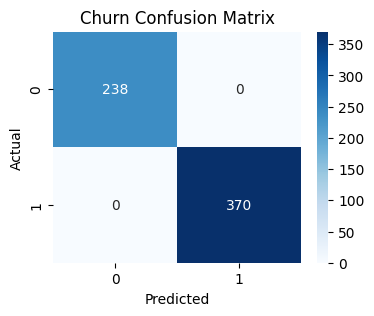

✅ Part 5 Complete: ML Model trained and evaluated.


In [ ]:
# --- PART 5: MACHINE LEARNING (CHURN PREDICTION) ---
print("--- Training Machine Learning Model ---")

# Target Variable (Churn = 1 if hasn't bought in 60 days)
rfm['churn'] = (rfm['recency'] > 60).astype(int)
X = rfm[['recency', 'frequency', 'monetary']]
y = rfm['churn']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build & Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Churn Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print("✅ Part 5 Complete: ML Model trained and evaluated.")

Mounted at /content/drive
Loading data...
Data merged successfully! Total rows: 9036

Generating Visualizations...


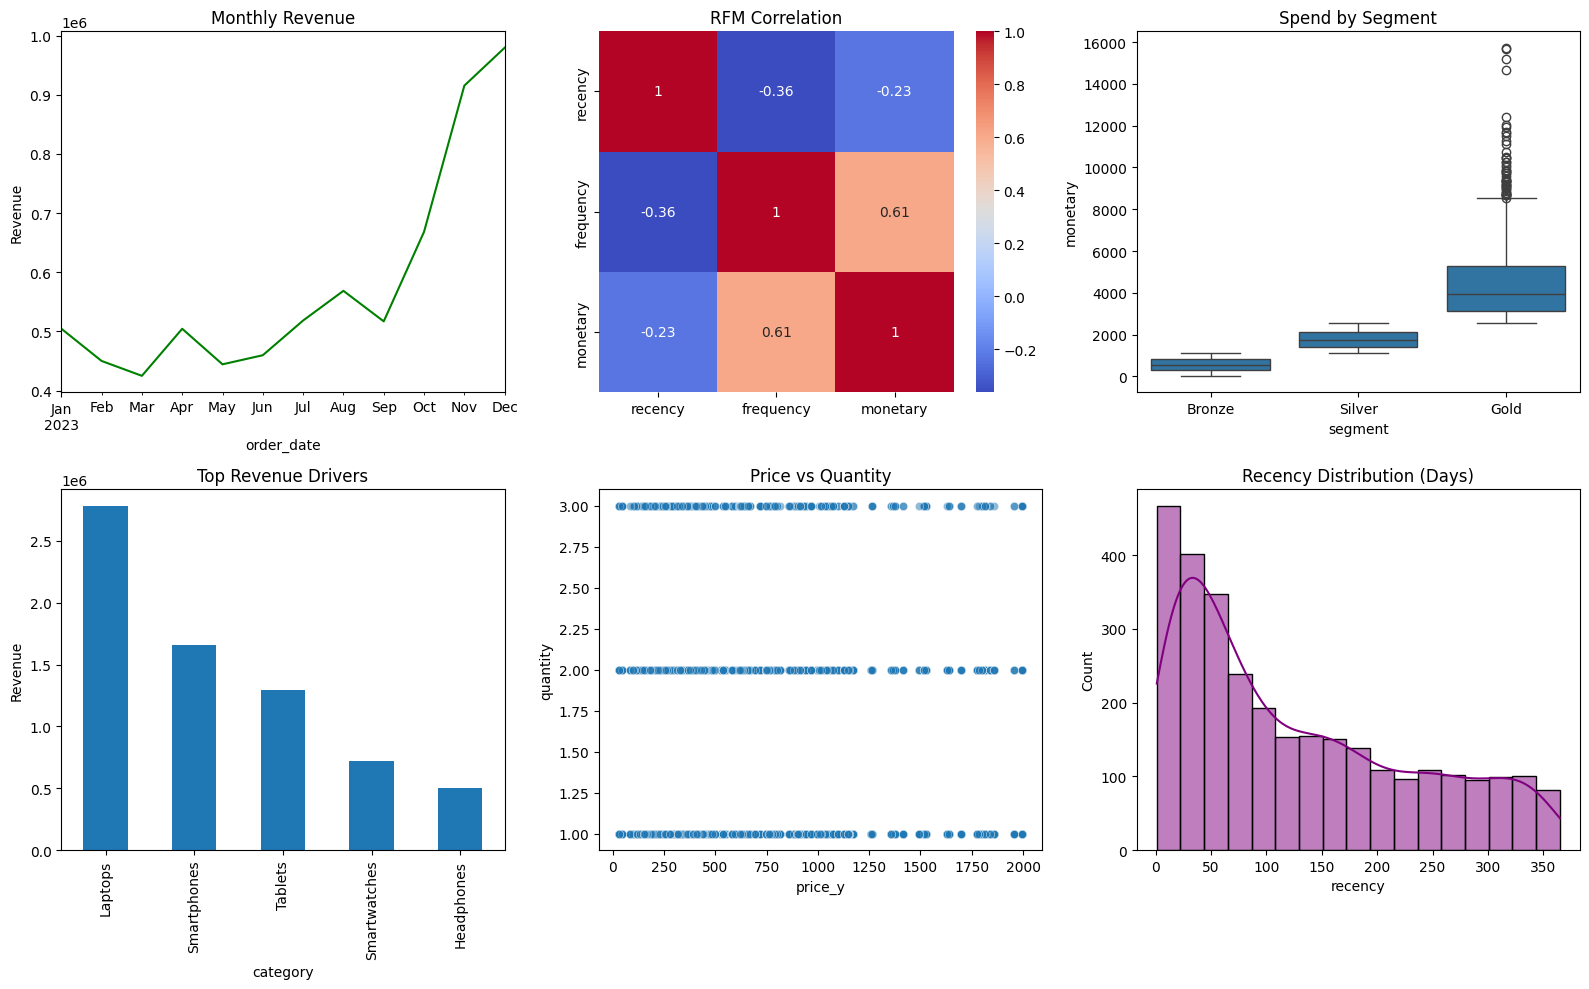


EXPLORATORY DATA ANALYSIS (EDA)

🔥 TOP 10 Products by Quantity Sold:
product_name
JBL Headphone Model 7          90
Apple Smartphone Model 12      81
HP Laptop Model 21             78
Fossil Smartwatche Model 17    76
Fossil Smartwatche Model 18    74
Fitbit Smartwatche Model 23    73
Apple Tablet Model 31          72
ASUS Laptop Model 14           72
Samsung Smartphone Model 26    72
HP Laptop Model 16             72

🧊 BOTTOM 10 Products by Quantity Sold:
product_name
Dell Laptop Model 10           41
Samsung Tablet Model 4         41
Sony Headphone Model 35        41
Fitbit Smartwatche Model 8     41
Dell Laptop Model 36           40
Fitbit Smartwatche Model 21    39
Samsung Tablet Model 8         36
Google Smartphone Model 40     36
Google Smartphone Model 19     35
Apple Smartwatche Model 24     34

⏰ Peak Shopping Hour: 0:00
⚠️ Found 1842 outlier transactions with unusually high quantities (above 1.0 units).

TRAINING MACHINE LEARNING MODEL

--- Classification Report ---
       

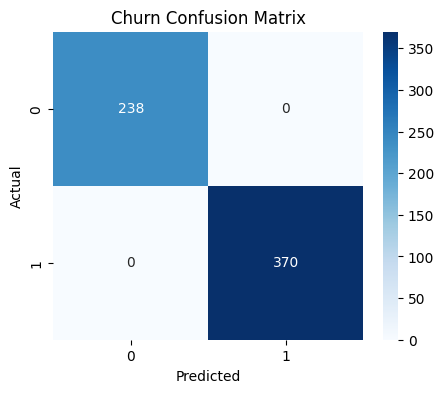


✅ Analysis Complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# PART 1: SETUP AND DATA LOADING
# ==========================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/MyDrive/Capstone Test Data sets/'
print("Loading data...")
trans_df = pd.read_csv(BASE_PATH + 'transactions.csv')
cust_df = pd.read_csv(BASE_PATH + 'customers.csv')
prod_df = pd.read_csv(BASE_PATH + 'products.csv')
items_df = pd.read_csv(BASE_PATH + 'order_items.csv')

# ==========================================
# PART 2: DATA CLEANING & MERGING
# ==========================================
# Clean column names
for temp_df in [trans_df, cust_df, prod_df, items_df]:
    temp_df.columns = temp_df.columns.str.strip().str.lower()

# Normalize price column
if 'unit_price' in prod_df.columns: prod_df.rename(columns={'unit_price': 'price'}, inplace=True)
if 'unit_price' in items_df.columns: items_df.rename(columns={'unit_price': 'price'}, inplace=True)

# Merge datasets securely
df = trans_df.merge(cust_df, on='customer_id')
df = df.merge(items_df, on='order_id')
df = df.merge(prod_df, on='product_id')
print(f"Data merged successfully! Total rows: {len(df)}")

# ==========================================
# PART 3: FEATURE ENGINEERING (RFM)
# ==========================================
df['order_date'] = pd.to_datetime(df['order_date'])

# Resolve duplicate price columns if they exist
price_col = 'price_y' if 'price_y' in df.columns else ('price_x' if 'price_x' in df.columns else 'price')
df['total_spent'] = df['quantity'] * df[price_col]

snapshot_date = df['order_date'].max() + timedelta(days=1)

# RFM Calculation
rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_spent': 'sum'
}).rename(columns={'order_date': 'recency', 'order_id': 'frequency', 'total_spent': 'monetary'})

# Assign Segments
rfm['segment'] = pd.qcut(rfm['monetary'].rank(method='first'), q=3, labels=['Bronze', 'Silver', 'Gold'])

# ==========================================
# PART 4: VISUALIZATIONS (6 CHARTS)
# ==========================================
print("\nGenerating Visualizations...")
plt.figure(figsize=(16, 10))

# 1. Revenue Trend
plt.subplot(2, 3, 1)
df.set_index('order_date')['total_spent'].resample('ME').sum().plot(title='Monthly Revenue', color='green')
plt.ylabel('Revenue')

# 2. Correlation Heatmap
plt.subplot(2, 3, 2)
sns.heatmap(rfm[['recency', 'frequency', 'monetary']].corr(), annot=True, cmap='coolwarm').set_title('RFM Correlation')

# 3. Spend by Segment
plt.subplot(2, 3, 3)
sns.boxplot(x='segment', y='monetary', data=rfm).set_title('Spend by Segment')

# 4. Category Performance
plt.subplot(2, 3, 4)
cat_col = 'category' if 'category' in df.columns else 'name'
df.groupby(cat_col)['total_spent'].sum().nlargest(10).plot(kind='bar', title='Top Revenue Drivers')
plt.ylabel('Revenue')

# 5. Price vs Sales Scatter
plt.subplot(2, 3, 5)
sns.scatterplot(data=df, x=price_col, y='quantity', alpha=0.5).set_title('Price vs Quantity')

# 6. Recency Distribution
plt.subplot(2, 3, 6)
sns.histplot(rfm['recency'], kde=True, color='purple').set_title('Recency Distribution (Days)')

plt.tight_layout()
plt.show()

# ==========================================
# PART 5: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
print("\n" + "="*40)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*40)

# Identify correct product name column
possible_name_cols = ['product_name', 'name_y', 'name_x', 'name', 'title', 'item_name']
prod_name_col = 'product_id' # Fallback
for col in possible_name_cols:
    if col in df.columns:
        prod_name_col = col
        break

# Top/Bottom Products
product_sales = df.groupby(prod_name_col)['quantity'].sum().sort_values(ascending=False)
print("\n🔥 TOP 10 Products by Quantity Sold:")
print(product_sales.head(10).to_string())

print("\n🧊 BOTTOM 10 Products by Quantity Sold:")
print(product_sales.tail(10).to_string())

# Peak Hours
df['hour'] = df['order_date'].dt.hour
peak_hour = df['hour'].value_counts().idxmax()
print(f"\n⏰ Peak Shopping Hour: {peak_hour}:00")

# Outliers
q3 = df['quantity'].quantile(0.75)
iqr = q3 - df['quantity'].quantile(0.25)
outlier_threshold = q3 + (1.5 * iqr)
outliers = df[df['quantity'] > outlier_threshold]
print(f"⚠️ Found {len(outliers)} outlier transactions with unusually high quantities (above {outlier_threshold} units).")

# ==========================================
# PART 6: MACHINE LEARNING (CHURN PREDICTION)
# ==========================================
print("\n" + "="*40)
print("TRAINING MACHINE LEARNING MODEL")
print("="*40)

# Target: Churn if no purchase in 60 days
rfm['churn'] = (rfm['recency'] > 60).astype(int)

X = rfm[['recency', 'frequency', 'monetary']]
y = rfm['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Churn Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\n✅ Analysis Complete!")